# Chapter 8 — War, Aviation, and the Acceleration of Truth
### *Modern Strain Gage Technology* — Companion Notebook

Companion notebook to Chapter 8 — War, Aviation, and the Acceleration of Truth.

A strain gage reads strain at one spot. A flight-loads engineer wants something else: the shear, bending moment, and torque that the whole wing or tail is carrying at a station near its root. Between 1944 and 1954 the NACA's Langley laboratory worked out a general way to get from one to the other, published as NACA Report 1178 (Skopinski, Aiken, and Huston, 1954). Apply known loads at many points on the real structure, record how every bridge responds, and fit coefficients so that a weighted sum of bridge outputs reproduces the applied load. The airframe becomes its own load cell.

This notebook reproduces the idea on a synthetic tail surface. Every number here is invented for illustration; the structure, the bridge sensitivities, and the noise are chosen so the effect is visible on a plot.

**This notebook demonstrates:**
1. The two-bridge worked example from the chapter, solved exactly (Eq. 8.1).
2. A nine-point calibration of three bridges fitted by least squares (Eq. 8.2), with residuals.
3. Why one bridge alone cannot measure bending moment: its apparent scale factor depends on where the load sits.
4. A distributed check load, predicted from the fitted load equation, as Report 1178 recommends.

In [1]:
# !pip install numpy matplotlib
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11, 'axes.titlesize': 12})

# Generated figures are written next to the chapter's other media.
# The file name matches the \includegraphics call in Chapter 8.
OUT_DIR = Path("../src/media/ch08")
OUT_DIR.mkdir(parents=True, exist_ok=True)

---
## 1 — The two-bridge worked example

The *load equation* writes a load at the gage station as a weighted sum of bridge responses:

$$M = \beta_1\mu_1 + \beta_2\mu_2 + \dots + \beta_j\mu_j \qquad (8.1)$$

Each response $\mu$ is nondimensional: the bridge output divided by its output when a known calibration resistor is shunted across one arm (the shunt calibration of Chapter 29). With two bridges and two calibration loads, the coefficients follow from two simultaneous equations. The values below are the chapter's worked example.

In [2]:
# Chapter 8 worked example: two moment bridges, two calibration loads.
# Rows = calibration loads (A near the front spar, B near the rear spar).
# Columns = responses of bridge 1 (front spar) and bridge 2 (rear spar).
mu_cal = np.array([[0.50, 0.10],
                   [0.25, 0.25]])
M_cal = np.array([10_000.0, 10_000.0])        # applied bending moment, N*m

beta = np.linalg.solve(mu_cal, M_cal)
print(f"beta_1 = {beta[0]:,.0f} N*m,  beta_2 = {beta[1]:,.0f} N*m")

# One bridge has no single scale factor: it depends on where the load sits.
print(f"Front bridge alone: {M_cal[0]/mu_cal[0,0]:,.0f} N*m per unit response under load A,"
      f" {M_cal[1]/mu_cal[1,0]:,.0f} under load B")

# In flight the two bridges read:
mu_flight = np.array([0.70, 0.50])
M_flight = beta @ mu_flight
print(f"In-flight bending moment = {M_flight:,.0f} N*m")

beta_1 = 15,000 N*m,  beta_2 = 25,000 N*m
Front bridge alone: 20,000 N*m per unit response under load A, 40,000 under load B
In-flight bending moment = 23,000 N*m


---
## 2 — A nine-point least-squares calibration

Real calibrations apply more loads than there are bridges, so the coefficients are found by least squares. Stacking the $n$ calibration loads into a column $\{M'\}$ and the bridge responses into an $n \times j$ matrix $[\mu]$, the coefficients that minimize the squared residuals are

$$\{\beta\} = \left([\mu]^{\mathsf T}[\mu]\right)^{-1}[\mu]^{\mathsf T}\{M'\} \qquad (8.2)$$

The synthetic tail below has three bridges at a root station: a bending bridge on the front spar, a bending bridge on the rear spar, and a shear bridge on the front-spar web. Each responds to shear, bending moment, *and* torque, plus a small term that no simple beam formula predicts. Nine point loads of 10 kN are applied on a 3 × 3 grid (three spanwise stations, three chordwise positions), as in Report 1178's straight stabilizer.

In [3]:
rng = np.random.default_rng(1954)   # seeded so the figure is reproducible

V_LOAD = 10.0                                   # kN, each calibration load
Y_PTS = np.array([1.0, 2.0, 3.0])               # m outboard of the gage station
X_PTS = np.array([0.30, 0.0, -0.30])            # m forward (+) of the torque axis
NOISE = 0.004                                   # reading noise, nondimensional


def bridge_responses(V, x, y):
    # Nondimensional responses of the three bridges to a point load V at (x, y).
    # Bending moment M = V*y and torque T = V*x about the station.
    # Coefficients are invented; the cross terms in V*x*y stand for the
    # load-path effects that a real built-up structure adds.
    M, T = V * y, V * x
    mu1 = 0.020 * M + 0.022 * T + 0.004 * V + 0.0015 * V * x * y   # front-spar bending
    mu2 = 0.018 * M - 0.012 * T + 0.003 * V - 0.0010 * V * x * y   # rear-spar bending
    mu3 = 0.040 * V + 0.002 * M + 0.020 * T                        # front-spar shear
    return np.array([mu1, mu2, mu3])


# --- calibration loads on the 3 x 3 grid ---
pts = [(x, y) for y in Y_PTS for x in X_PTS]
M_applied = np.array([V_LOAD * y for x, y in pts])                 # kN*m
MU = np.array([bridge_responses(V_LOAD, x, y) for x, y in pts])
MU += rng.normal(0.0, NOISE, MU.shape)

# --- Eq. 8.2: least-squares load coefficients for bending moment ---
beta_M, *_ = np.linalg.lstsq(MU, M_applied, rcond=None)
M_fit = MU @ beta_M
resid = M_fit - M_applied
pe_rms = np.sqrt(np.sum(resid**2) / (len(M_applied) - len(beta_M)))
print("beta (kN*m per unit response):", np.round(beta_M, 1))
print(f"RMS error of the three-bridge load equation: {pe_rms:.2f} kN*m")

# --- single-bridge estimates, each given its own best scale factor ---
single = {}
for j, name in [(0, 'front'), (1, 'rear')]:
    k = np.sum(MU[:, j] * M_applied) / np.sum(MU[:, j] ** 2)
    single[name] = k * MU[:, j]
    err = single[name] - M_applied
    print(f"{name:>5} bridge alone: worst error {np.max(np.abs(err)):.1f} kN*m "
          f"({100*np.max(np.abs(err/M_applied)):.0f}% of the applied moment)")

# --- distributed check load: four 5 kN loads along x = +0.10 m ---
chk = [(0.10, y) for y in (0.75, 1.50, 2.25, 3.00)]
M_chk = sum(5.0 * y for x, y in chk)
mu_chk = sum(bridge_responses(5.0, x, y) for x, y in chk) + rng.normal(0.0, NOISE, 3)
M_chk_pred = mu_chk @ beta_M
print(f"Check load: applied {M_chk:.1f} kN*m, predicted {M_chk_pred:.1f} kN*m "
      f"({100*(M_chk_pred-M_chk)/M_chk:+.1f}%)")

beta (kN*m per unit response): [22.2 32.  -5.1]
RMS error of the three-bridge load equation: 0.13 kN*m
front bridge alone: worst error 4.5 kN*m (41% of the applied moment)
 rear bridge alone: worst error 3.2 kN*m (29% of the applied moment)
Check load: applied 37.5 kN*m, predicted 37.6 kN*m (+0.1%)


---
## 3 — The figure

Panel (a) is a plan view of the synthetic tail surface: the gage station at the root, the two spars, and the nine calibration load points. Panel (b) plots predicted against applied bending moment. Each single bridge, even given its best possible scale factor, scatters with chordwise position because it also feels torque; the three-bridge load equation lies on the line, and so does the distributed check load it was never fitted to. Series are distinguished by marker shape as well as color, so the figure reads in grayscale.

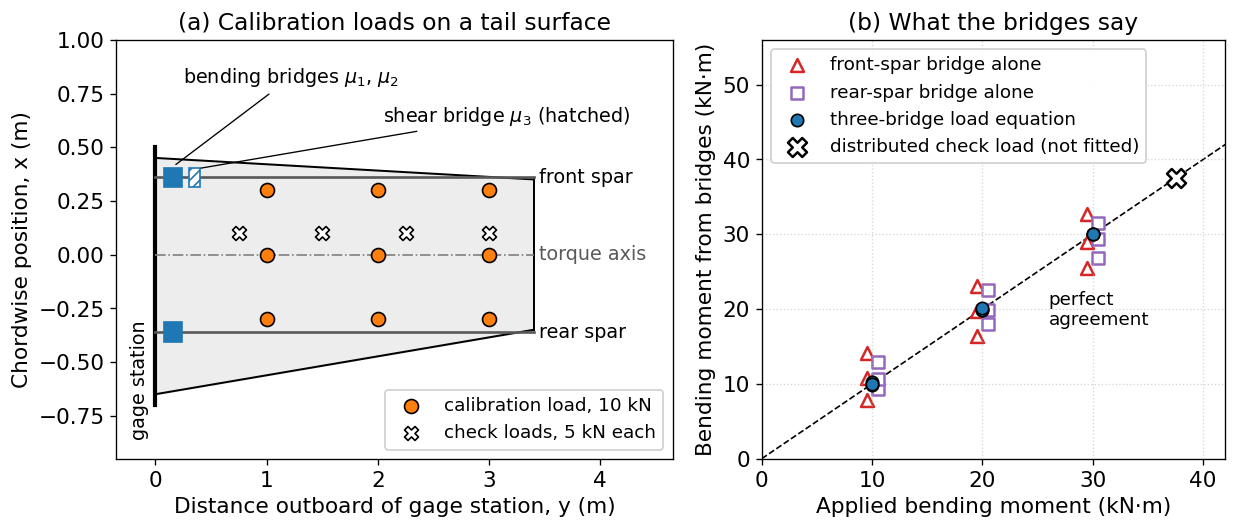

In [4]:
plt.rcParams.update({'font.size': 13, 'axes.titlesize': 14})
fig, (axa, axb) = plt.subplots(1, 2, figsize=(10.5, 4.6),
                               gridspec_kw={'width_ratios': [1.2, 1.0]})

# ---------- (a) plan view ----------
span, c_root, c_tip = 3.4, 1.10, 0.70
le = lambda y: 0.45 - 0.10 * y / span        # leading edge (forward is +x)
te = lambda y: le(y) - (c_root + (c_tip - c_root) * y / span)
ys = np.linspace(0, span, 50)
axa.fill_between(ys, te(ys), le(ys), color='0.93', zorder=0)
axa.plot(ys, le(ys), color='black', lw=1.2)
axa.plot(ys, te(ys), color='black', lw=1.2)
axa.plot([span, span], [te(span), le(span)], color='black', lw=1.2)
axa.plot([0, 0], [te(0) - 0.05, le(0) + 0.05], color='black', lw=2.5)

# spars and torque reference axis
axa.plot([0, span], [0.36, 0.36], color='0.35', lw=1.6, ls='-')
axa.plot([0, span], [-0.36, -0.36], color='0.35', lw=1.6, ls='-')
axa.plot([0, span], [0.0, 0.0], color='0.5', lw=1.0, ls='-.')
axa.text(span + 0.05, 0.36, 'front spar', va='center', fontsize=11.5)
axa.text(span + 0.05, -0.36, 'rear spar', va='center', fontsize=11.5)
axa.text(span + 0.05, 0.0, 'torque axis', va='center', fontsize=11.5, color='0.35')

# bridges at the gage station
for yb, lab in [(0.36, r'bridge 1 ($\mu_1$), bending'), (-0.36, r'bridge 2 ($\mu_2$), bending')]:
    axa.add_patch(plt.Rectangle((0.08, yb - 0.045), 0.16, 0.09, color='tab:blue', zorder=3))
axa.add_patch(plt.Rectangle((0.30, 0.36 - 0.045), 0.10, 0.09, facecolor='white',
                            edgecolor='tab:blue', hatch='////', zorder=3))
axa.annotate(r'bending bridges $\mu_1$, $\mu_2$', xy=(0.16, 0.41), xytext=(0.25, 0.80),
             fontsize=11.5, arrowprops=dict(arrowstyle='-', lw=0.8))
axa.annotate(r'shear bridge $\mu_3$ (hatched)', xy=(0.38, 0.40), xytext=(2.05, 0.62),
             fontsize=11.5, arrowprops=dict(arrowstyle='-', lw=0.8))
axa.text(-0.06, -0.86, 'gage station', rotation=90, fontsize=11.5, va='bottom', ha='right')

# calibration loads and check loads
axa.scatter([y for x, y in pts], [x for x, y in pts], marker='o', s=70,
            facecolor='tab:orange', edgecolor='black', zorder=4, label='calibration load, 10 kN')
axa.scatter([y for x, y in chk], [x for x, y in chk], marker='X', s=70,
            facecolor='white', edgecolor='black', zorder=4, label='check loads, 5 kN each')
axa.set_xlim(-0.35, span + 1.25)
axa.set_ylim(-0.95, 1.0)
axa.set_xlabel('Distance outboard of gage station, y (m)')
axa.set_ylabel('Chordwise position, x (m)')
axa.set_title('(a) Calibration loads on a tail surface')
axa.legend(loc='lower right', fontsize=11, framealpha=0.95)
axa.set_aspect('auto')

# ---------- (b) predicted vs applied ----------
lim = [0, 42]
axb.plot(lim, lim, color='black', lw=1.0, ls='--', zorder=1)
axb.text(26.0, 22.5, 'perfect\nagreement', fontsize=11, ha='left', va='top')
axb.scatter(M_applied - 0.5, single['front'], marker='^', s=60, facecolor='white',
            edgecolor='tab:red', lw=1.5, label='front-spar bridge alone')
axb.scatter(M_applied + 0.5, single['rear'], marker='s', s=55, facecolor='white',
            edgecolor='tab:purple', lw=1.5, label='rear-spar bridge alone')
axb.scatter(M_applied, M_fit, marker='o', s=55, color='tab:blue', edgecolor='black',
            zorder=3, label='three-bridge load equation')
axb.scatter([M_chk], [M_chk_pred], marker='X', s=130, color='white', edgecolor='black',
            lw=1.5, zorder=4, label='distributed check load (not fitted)')
axb.set_xlim(lim); axb.set_ylim(0, 56)
axb.set_xlabel('Applied bending moment (kN·m)')
axb.set_ylabel('Bending moment from bridges (kN·m)')
axb.set_title('(b) What the bridges say')
axb.legend(loc='upper left', fontsize=11, framealpha=0.95)
axb.grid(True, ls=':', alpha=0.5)

plt.tight_layout()
plt.savefig(OUT_DIR / 'fig08_nb1_load_calibration.png', bbox_inches='tight', dpi=300)
plt.show()

---
## Where to take this next

1. **Add torque and shear equations.** Fit $\{\beta\}$ for torque $T' = Vx$ and for shear $V'$ from the same nine loads. Report 1178 derives all three from one calibration.
2. **Make two bridges nearly alike.** Change bridge 2's coefficients until they approach a multiple of bridge 1's and watch the coefficients and their uncertainties grow. That is the redundancy Report 1178 warns about, and the ill-conditioning that Chapter 52 meets again in regression.
3. **Combine electrically.** Scale the outputs by $\beta_j/\beta_{\max}$ and add them, as attenuating resistors did in 1950, so that a single recorded trace reads bending moment directly. Then add noise to the individual bridges and compare.